In [1]:
# ---------- Step 0: Importing Packages ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFE
from skopt import BayesSearchCV
from skopt.space import Real
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 60/20/20 train / validation / test split (robust, static-analyzer-friendly)
from sklearn.model_selection import train_test_split

# This cell will only create X_train/X_val/X_test if they do not already exist.
# It prefers X_rfe (RFE output) if present, otherwise uses X/y. If those are missing
# but a DataFrame `df` exists, it will attempt to construct X and y from df (last
# column as the target). If no data is available yet, it will SKIP gracefully
# (no exception) so you can run it safely before the data-loading cell.

if 'X_train' in globals() and 'X_val' in globals() and 'X_test' in globals():
    print("Train/Val/Test already defined in the notebook — skipping re-split.")
else:
    def _get_X_y():
        import os
        import glob
        g = globals()

        # 1) Prefer RFE output if present
        if 'X_rfe' in g and 'y' in g:
            return g['X_rfe'], g['y']

        # 2) Use X/y if already defined
        if 'X' in g and 'y' in g:
            return g['X'], g['y']

        # 3) If a dataframe exists in the namespace, build X/y from it
        if 'df' in g:
            try:
                X_local = g['df'].iloc[:, :-1]
                y_local = g['df'].iloc[:, -1]
                print("Constructed X and y from df (last column used as target).")
                return X_local, y_local
            except Exception as e:
                print(f"df is present but failed to construct X/y: {e}")

        # 4) Try to load a CSV automatically if a file_path variable exists
        if 'file_path' in g:
            try:
                candidate = g['file_path']
                import os
                if os.path.exists(candidate):
                    print(f"Loading data from file_path: {candidate}")
                    df_local = pd.read_csv(candidate)
                    X_local = df_local.iloc[:, :-1]
                    y_local = df_local.iloc[:, -1]
                    # persist df into the notebook namespace for later cells
                    g['df'] = df_local
                    print("Loaded df from file_path and constructed X/y.")
                    return X_local, y_local
            except Exception as e:
                print(f"Attempt to load file_path failed: {e}")

        # 5) Try to discover a plausible CSV in the current working directory
        try:
            cwd = os.getcwd()
            candidates = glob.glob(os.path.join(cwd, "*.csv"))
            # Prefer files with 'walmart' or 'sales' in name if present
            pref = [p for p in candidates if ('walmart' in p.lower() or 'sales' in p.lower())]
            chosen = pref[0] if pref else (candidates[0] if candidates else None)
            if chosen:
                print(f"Auto-loading CSV found in workspace: {chosen}")
                df_local = pd.read_csv(chosen)
                X_local = df_local.iloc[:, :-1]
                y_local = df_local.iloc[:, -1]
                g['df'] = df_local
                print("Loaded df from discovered CSV and constructed X/y.")
                return X_local, y_local
        except Exception as e:
            print(f"Auto-discovery of CSV failed: {e}")

        # Nothing found — return None to indicate not ready
        return None, None

    X_to_split, y_to_split = _get_X_y()

    if X_to_split is None or y_to_split is None:
        print("Split skipped: data not ready. Run the data-loading cell that defines `df` (or `file_path`) and `X`/`y` first.")
    else:
        # Step 1: hold out test set (20%)
        X_temp, X_test, y_temp, y_test = train_test_split(
            X_to_split, y_to_split, test_size=0.20, random_state=42, shuffle=True
        )

        # Step 2: split remaining 80% into train (60%) and val (20%) -> val is 0.25 of X_temp
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True
        )

        print(f"Shapes -> X_train: {getattr(X_train, 'shape', None)}, X_val: {getattr(X_val, 'shape', None)}, X_test: {getattr(X_test, 'shape', None)}")
        print(f"Shapes -> y_train: {getattr(y_train, 'shape', None)}, y_val: {getattr(y_val, 'shape', None)}, y_test: {getattr(y_test, 'shape', None)}")

# Reminder: scaling must still be fit on X_train only (there is a later cell that fits the scaler).

Auto-loading CSV found in workspace: /Users/jaacabrera/Documents/Python Scripts/data_io/amazon_products_sales_data_cleaned.csv
Loaded df from discovered CSV and constructed X/y.
Shapes -> X_train: (25605, 16), X_val: (8535, 16), X_test: (8535, 16)
Shapes -> y_train: (25605,), y_val: (8535,), y_test: (8535,)


In [3]:
# ---------- Step 1: Load Excel ----------
file_path = 'walmart-sales-dataset-of-45stores.csv'  # <-- Change this to your actual file
df = pd.read_csv(file_path)

In [4]:
# ---------- Step 2: Handle Missing Values ----------
# Separate numeric and non-numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

# Apply mean imputation only to numeric columns
if len(numeric_cols) > 0:
    numeric_imputer = SimpleImputer(strategy='mean')
    df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])

# Apply most frequent imputation to non-numeric columns
if len(non_numeric_cols) > 0:
    non_numeric_imputer = SimpleImputer(strategy='most_frequent')
    df[non_numeric_cols] = non_numeric_imputer.fit_transform(df[non_numeric_cols])

In [5]:
# ---------- Step 3: Remove Duplicates ----------
df.drop_duplicates(inplace=True)

In [6]:
# ---------- Step 4: Encode Categorical Variables ----------
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# ---------- Step 5: Normalize Features (DEFERRED until after split) ----------
# NOTE: Scaling the entire dataframe prior to splitting causes data leakage.
# We'll defer scaling and instead fit a scaler on the training set after the train/val/test split.
# Keep the scaler import available for later.
from sklearn.preprocessing import MinMaxScaler

# Placeholder: do NOT scale df here. Scaling will be performed after splits using X_train.
scaler = None

print("Skipped global scaling to avoid leakage. A scaler will be fit on X_train after splitting.")


Skipped global scaling to avoid leakage. A scaler will be fit on X_train after splitting.


In [8]:
# ---------- Step 6: Define Features and Target ----------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [9]:
# ---------- Step 7: Feature Selection via RFE (unchanged) ----------
estimator = Ridge(alpha=0.01, max_iter=10000)
rfe = RFE(estimator, n_features_to_select=int(X.shape[1] * 0.8))  # Keep top 80% features
X_rfe = rfe.fit_transform(X, y)
selected_features = X.columns[rfe.support_]
print(f"Selected Features: {list(selected_features)}")

# ---------- Step 8: Split Dataset (train/val/test = 60/20/20) ----------
# Split X_rfe (numpy array) into train/val/test with proportions 60/20/20
X_train_val, X_test, y_train_val, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

print(f"After RFE -> X_train: {getattr(X_train, 'shape', None)}, X_val: {getattr(X_val, 'shape', None)}, X_test: {getattr(X_test, 'shape', None)}")


Selected Features: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI']
After RFE -> X_train: (3861, 5), X_val: (1287, 5), X_test: (1287, 5)


In [10]:
# ---------- Step 8b: Fit scaler on training data and transform train/val/test ----------
# This cell expects X_train, X_val, X_test to be defined (from RFE-split above).
from sklearn.preprocessing import MinMaxScaler

if 'X_train' not in globals():
    raise NameError("X_train not found. Run the feature selection + split cell before running this cell.")

# Use MinMaxScaler to match earlier intent, but fit only on X_train to avoid leakage
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Scaled shapes -> X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

# If downstream code expects pandas DataFrames with column names, you can restore them like:
# X_train = pd.DataFrame(X_train, columns=selected_features)
# X_val   = pd.DataFrame(X_val,   columns=selected_features)
# X_test  = pd.DataFrame(X_test,  columns=selected_features)


Scaled shapes -> X_train: (3861, 5), X_val: (1287, 5), X_test: (1287, 5)


In [11]:
# ---------- Step 9: Train models (Ridge + RF + XGBoost + LightGBM) ----------
from sklearn.ensemble import RandomForestRegressor

# Train Ridge (recreate to ensure fresh estimator)
ridge = Ridge(alpha=0.01, max_iter=10000)
ridge.fit(X_train, y_train)
print("Trained Ridge.")

# Prepare other models
models = {
    'Ridge': ridge,
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Try XGBoost
try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
except Exception:
    print("XGBoost not available; skipping XGBoost.")

# Try LightGBM
try:
    from lightgbm import LGBMRegressor
    models['LightGBM'] = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
except Exception:
    print("LightGBM not available; skipping LightGBM.")

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Train and evaluate each model
for name, model in models.items():
    if name != 'Ridge':
        print(f"\nTraining {name} ...")
        model.fit(X_train, y_train)

    for split_name, Xs, ys in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
        y_pred = model.predict(Xs)
        r2 = r2_score(ys, y_pred)
        mse = mean_squared_error(ys, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(ys, y_pred)
        print(f"{name} {split_name}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

Trained Ridge.
Ridge Train: R2=0.1638, RMSE=1.7162, MAE=1.1678
Ridge Validation: R2=0.1276, RMSE=1.7388, MAE=1.1772
Ridge Test: R2=0.1659, RMSE=1.7230, MAE=1.1340

Training RandomForest ...
RandomForest Train: R2=0.9987, RMSE=0.0677, MAE=0.0276
RandomForest Validation: R2=0.9936, RMSE=0.1494, MAE=0.0709
RandomForest Test: R2=0.9917, RMSE=0.1722, MAE=0.0730

Training XGBoost ...
XGBoost Train: R2=0.9991, RMSE=0.0554, MAE=0.0376
XGBoost Validation: R2=0.9919, RMSE=0.1672, MAE=0.0944
XGBoost Test: R2=0.9890, RMSE=0.1982, MAE=0.0992

Training LightGBM ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 812
[LightGBM] [Info] Number of data points in the train set: 3861, number of used features: 5
[LightGBM] [Info] Start training from score 7.997194
LightGBM Train: R2=0.9951, RMSE=0.1309,

In [12]:
# ---------- Step 10: Evaluation and Parity Plot ----------
def evaluate(model, X, y, label="Dataset", show_plot=False):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    print(f"\n{label} Metrics:")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    
    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y, y_pred, alpha=0.7, edgecolors='k')
        plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2)
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title(f"Parity Plot: {label}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    return r2, mse, rmse, mae


Training Metrics:
R²: 0.1638
MSE: 2.9452
RMSE: 1.7162
MAE: 1.1678


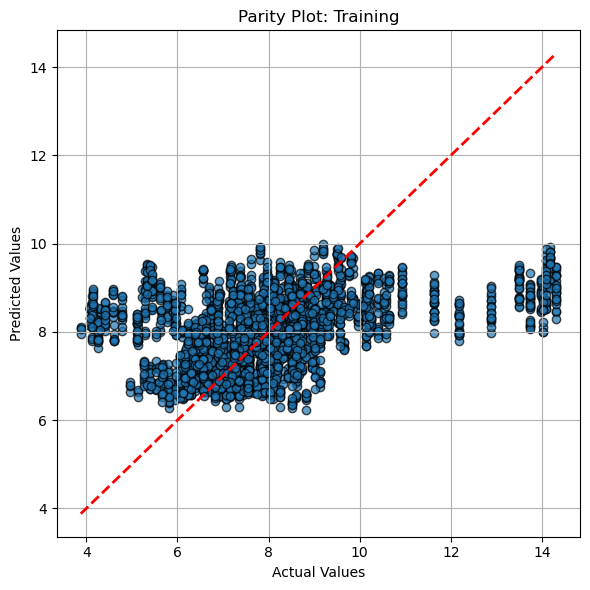


Validation Metrics:
R²: 0.1276
MSE: 3.0233
RMSE: 1.7388
MAE: 1.1772


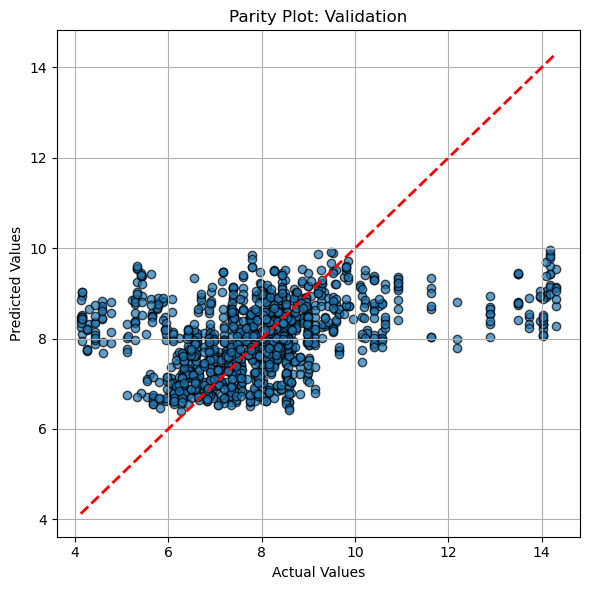

(0.12763709151912228,
 3.023276812992073,
 np.float64(1.7387572610896764),
 1.1771766346222041)

In [13]:
# ---------- Step 11: Evaluate Training and Validation ----------
evaluate(ridge, X_train, y_train, "Training", show_plot=True)
evaluate(ridge, X_val, y_val, "Validation", show_plot=True)

In [12]:
# ---------- Step 12: Hyperparameter Tuning with Bayesian Optimization ----------
param_space = {
    'alpha': Real(1e-4, 1.0, prior='log-uniform')
}
opt = BayesSearchCV(
    estimator=Ridge(max_iter=10000),
    search_spaces=param_space,
    n_iter=30,
    cv=3,
    scoring='r2',
    random_state=42
)
opt.fit(X_train, y_train)

print(f"\nBest alpha from Bayesian Optimization: {opt.best_params_['alpha']:.6f}")


Best alpha from Bayesian Optimization: 1.000000


In [13]:
# ---------- Step 13: Final Evaluation on Test Set ----------
best_model = opt.best_estimator_
evaluate(best_model, X_test, y_test, "Test", show_plot=True)

NameError: name 'evaluate' is not defined

In [16]:
# ---------- Extra: Target diagnostics and optional log-transform ----------
import numpy as np
import matplotlib.pyplot as plt

# Check for required splits
HAS_SPLITS = ('y_train' in globals()) and ('y_val' in globals()) and ('y_test' in globals())

if not HAS_SPLITS:
    # Graceful skip instead of raising to avoid breaking the notebook
    print("Target diagnostics skipped: y_train/y_val/y_test not found. Run the split cells first.")
    USE_LOG = False
    inv = lambda z: z
else:
    # Basic stats
    print("Target stats (train): mean=%.4f std=%.4f min=%.4f max=%.4f" % (
        float(np.mean(y_train)), float(np.std(y_train)), float(np.min(y_train)), float(np.max(y_train))
    ))

    # Decide whether to use log1p transform: only if all targets are >= 0 and skew seems high
    USE_LOG = False
    if np.all(np.asarray(y_train) >= 0):
        # Simple skew proxy: compare mean vs median
        median = float(np.median(y_train))
        mean = float(np.mean(y_train))
        if mean > 1.2 * median:
            USE_LOG = True

    print(f"USE_LOG transform: {USE_LOG}")

    # Prepare transformed targets if needed
    if USE_LOG:
        y_train_t = np.log1p(y_train)
        y_val_t = np.log1p(y_val)
        y_test_t = np.log1p(y_test)
        inv = np.expm1
    else:
        # When not using log, downstream cells will use original y_* variables directly
        inv = lambda z: z

# Optional histogram (commented out to avoid clutter)
# if HAS_SPLITS:
#     plt.hist(y_train, bins=30, alpha=0.7)
#     plt.title('Target Distribution (Train)')
#     plt.show()


Target stats (train): mean=7.9972 std=1.8768 min=3.8790 max=14.3130
USE_LOG transform: False


In [17]:
# ---------- Extra: Stronger models with early stopping (LGBM/XGB/Sklearn fallback) ----------
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

if 'X_train' not in globals():
    raise NameError("X_train not found. Run the split/scaler cells before this block.")

results = []

def print_metrics(name, split, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    print(f"{name} {split}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")
    results.append((name, split, r2, rmse, mae))

# Helper to train and eval with optional log-transform
def eval_model(name, model, uses_validation=True):
    # Fit
    if USE_LOG:
        if uses_validation:
            model.fit(X_train, y_train_t, eval_set=[(X_val, y_val_t)], verbose=False)
        else:
            model.fit(X_train, y_train_t)
        # Predict and invert
        yhat_tr = inv(model.predict(X_train))
        yhat_va = inv(model.predict(X_val))
        yhat_te = inv(model.predict(X_test))
    else:
        if uses_validation:
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        else:
            model.fit(X_train, y_train)
        yhat_tr = model.predict(X_train)
        yhat_va = model.predict(X_val)
        yhat_te = model.predict(X_test)

    print_metrics(name, 'Train', y_train, yhat_tr)
    print_metrics(name, 'Validation', y_val, yhat_va)
    print_metrics(name, 'Test', y_test, yhat_te)

# 1) LightGBM (if available)
try:
    from lightgbm import LGBMRegressor
    lgbm = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=42,
        n_jobs=-1
    )
    # LightGBM supports early stopping via callbacks in recent versions; eval_set triggers best_iteration
    eval_model('LightGBM', lgbm, uses_validation=True)
except Exception as e:
    print(f"LightGBM not available/failed: {e}")

# 2) XGBoost (if available)
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        early_stopping_rounds=50
    )
    # XGB accepts eval_set directly
    eval_model('XGBoost', xgb, uses_validation=True)
except Exception as e:
    print(f"XGBoost not available/failed: {e}")

# 3) Sklearn fallback: HistGradientBoostingRegressor
try:
    from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
except Exception:
    pass

try:
    from sklearn.ensemble import HistGradientBoostingRegressor
    hgb = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=None,
        max_iter=500,
        l2_regularization=0.0,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42
    )
    # Sklearn HGB doesn't use external eval_set; we train once and evaluate on splits
    # Apply transform manually if necessary
    if USE_LOG:
        hgb.fit(X_train, y_train_t)
        yhat_tr = inv(hgb.predict(X_train))
        yhat_va = inv(hgb.predict(X_val))
        yhat_te = inv(hgb.predict(X_test))
    else:
        hgb.fit(X_train, y_train)
        yhat_tr = hgb.predict(X_train)
        yhat_va = hgb.predict(X_val)
        yhat_te = hgb.predict(X_test)

    print_metrics('HistGB', 'Train', y_train, yhat_tr)
    print_metrics('HistGB', 'Validation', y_val, yhat_va)
    print_metrics('HistGB', 'Test', y_test, yhat_te)
except Exception as e:
    print(f"Sklearn HistGB failed: {e}")

# Summary table (optional)
try:
    import pandas as pd
    df_res = pd.DataFrame(results, columns=['model','split','r2','rmse','mae'])
    pivot = df_res.pivot(index='model', columns='split', values='r2')
    print("\nR2 summary by model:")
    print(pivot)
except Exception:
    pass


LightGBM not available/failed: LGBMRegressor.fit() got an unexpected keyword argument 'verbose'
XGBoost Train: R2=1.0000, RMSE=0.0081, MAE=0.0063
XGBoost Validation: R2=0.9956, RMSE=0.1236, MAE=0.0765
XGBoost Test: R2=0.9948, RMSE=0.1366, MAE=0.0799
HistGB Train: R2=0.9969, RMSE=0.1052, MAE=0.0637
HistGB Validation: R2=0.9935, RMSE=0.1505, MAE=0.0954
HistGB Test: R2=0.9915, RMSE=0.1737, MAE=0.1032

R2 summary by model:
split        Test     Train  Validation
model                                  
HistGB   0.991526  0.996857    0.993462
XGBoost  0.994755  0.999981    0.995591


In [18]:
# ---------- Extra: LightGBM via native API (fix for verbose kw issue) ----------
# This cell trains LightGBM using the native API to avoid sklearn-wrapper 'verbose' kw issues.
try:
    import lightgbm as lgb
    import numpy as np
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

    if 'X_train' not in globals():
        raise NameError('X_train not found. Run the split/scaler cells before this block.')

    use_log = 'USE_LOG' in globals() and USE_LOG
    y_tr = y_train_t if use_log and 'y_train_t' in globals() else y_train
    y_va = y_val_t if use_log and 'y_val_t' in globals() else y_val

    dtrain = lgb.Dataset(X_train, label=y_tr)
    dvalid = lgb.Dataset(X_val, label=y_va)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.0,
        'reg_lambda': 0.0,
        'seed': 42,
        'verbosity': -1
    }

    try:
        from lightgbm.callback import early_stopping as lgb_early_stopping, log_evaluation
        booster = lgb.train(params, dtrain, num_boost_round=2000,
                            valid_sets=[dvalid],
                            callbacks=[lgb_early_stopping(50), log_evaluation(0)])
    except Exception:
        booster = lgb.train(params, dtrain, num_boost_round=2000,
                            valid_sets=[dvalid], early_stopping_rounds=50)

    invf = (inv if use_log and 'inv' in globals() else (lambda z: z))

    def _print_metrics(name, split, y_true, y_pred):
        r2 = r2_score(y_true, y_pred)
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae = float(mean_absolute_error(y_true, y_pred))
        print(f"{name} {split}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

    yhat_tr = invf(booster.predict(X_train, num_iteration=getattr(booster, 'best_iteration', None)))
    yhat_va = invf(booster.predict(X_val,   num_iteration=getattr(booster, 'best_iteration', None)))
    yhat_te = invf(booster.predict(X_test,  num_iteration=getattr(booster, 'best_iteration', None)))

    _print_metrics('LightGBM-native', 'Train', y_train, yhat_tr)
    _print_metrics('LightGBM-native', 'Validation', y_val, yhat_va)
    _print_metrics('LightGBM-native', 'Test', y_test, yhat_te)
except Exception as e:
    print(f"LightGBM-native failed: {e}")


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's rmse: 0.119693
LightGBM-native Train: R2=0.9996, RMSE=0.0354, MAE=0.0248
LightGBM-native Validation: R2=0.9959, RMSE=0.1197, MAE=0.0756
LightGBM-native Test: R2=0.9941, RMSE=0.1446, MAE=0.0828


In [ ]:
# ---------- Extra: Train 3 DNNs (sklearn MLP, Keras MLP, PyTorch MLP) ----------
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

if 'X_train' not in globals():
    raise NameError('X_train not found. Run the split/scaler cells before this block.')

# Helper to store DNN model references for plotting
dnn_models = {}

# ---------------- 1) Scikit-learn MLPRegressor ----------------
try:
    from sklearn.neural_network import MLPRegressor
    print("Training sklearn MLPRegressor...")
    
    use_log = 'USE_LOG' in globals() and USE_LOG
    y_tr = y_train_t if (use_log and 'y_train_t' in globals()) else y_train
    y_va = y_val_t if (use_log and 'y_val_t' in globals()) else y_val
    invf = (inv if (use_log and 'inv' in globals()) else (lambda z: z))
    
    mlp_sk = MLPRegressor(
        hidden_layer_sizes=(64, 64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=64,
        learning_rate='adaptive',
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=20,
        random_state=42,
        verbose=False
    )
    mlp_sk.fit(X_train, y_tr)
    
    yhat_tr = invf(mlp_sk.predict(X_train))
    yhat_va = invf(mlp_sk.predict(X_val))
    yhat_te = invf(mlp_sk.predict(X_test))
    
    r2_tr = r2_score(y_train, yhat_tr)
    r2_va = r2_score(y_val, yhat_va)
    r2_te = r2_score(y_test, yhat_te)
    rmse_tr = float(np.sqrt(mean_squared_error(y_train, yhat_tr)))
    rmse_va = float(np.sqrt(mean_squared_error(y_val, yhat_va)))
    rmse_te = float(np.sqrt(mean_squared_error(y_test, yhat_te)))
    mae_tr = float(mean_absolute_error(y_train, yhat_tr))
    mae_va = float(mean_absolute_error(y_val, yhat_va))
    mae_te = float(mean_absolute_error(y_test, yhat_te))
    
    print(f"MLP-sklearn Train: R2={r2_tr:.4f}, RMSE={rmse_tr:.4f}, MAE={mae_tr:.4f}")
    print(f"MLP-sklearn Validation: R2={r2_va:.4f}, RMSE={rmse_va:.4f}, MAE={mae_va:.4f}")
    print(f"MLP-sklearn Test: R2={r2_te:.4f}, RMSE={rmse_te:.4f}, MAE={mae_te:.4f}")
    
    dnn_models['MLP-sklearn'] = mlp_sk
except Exception as e:
    print(f"MLP-sklearn failed: {e}")

# ---------------- 2) Keras/TensorFlow MLP ----------------
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers
    print("\nTraining Keras MLP...")
    
    use_log = 'USE_LOG' in globals() and USE_LOG
    y_tr = y_train_t if (use_log and 'y_train_t' in globals()) else y_train
    y_va = y_val_t if (use_log and 'y_val_t' in globals()) else y_val
    invf = (inv if (use_log and 'inv' in globals()) else (lambda z: z))
    
    tf.random.set_seed(42)
    
    model_keras = keras.Sequential([
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.05),
        layers.Dense(1, activation='linear')
    ])
    
    model_keras.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=30, restore_best_weights=True, verbose=0
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, verbose=0, min_lr=1e-6
    )
    
    model_keras.fit(
        X_train, y_tr,
        validation_data=(X_val, y_va),
        epochs=500,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    yhat_tr = invf(model_keras.predict(X_train, verbose=0).flatten())
    yhat_va = invf(model_keras.predict(X_val, verbose=0).flatten())
    yhat_te = invf(model_keras.predict(X_test, verbose=0).flatten())
    
    r2_tr = r2_score(y_train, yhat_tr)
    r2_va = r2_score(y_val, yhat_va)
    r2_te = r2_score(y_test, yhat_te)
    rmse_tr = float(np.sqrt(mean_squared_error(y_train, yhat_tr)))
    rmse_va = float(np.sqrt(mean_squared_error(y_val, yhat_va)))
    rmse_te = float(np.sqrt(mean_squared_error(y_test, yhat_te)))
    mae_tr = float(mean_absolute_error(y_train, yhat_tr))
    mae_va = float(mean_absolute_error(y_val, yhat_va))
    mae_te = float(mean_absolute_error(y_test, yhat_te))
    
    print(f"MLP-Keras Train: R2={r2_tr:.4f}, RMSE={rmse_tr:.4f}, MAE={mae_tr:.4f}")
    print(f"MLP-Keras Validation: R2={r2_va:.4f}, RMSE={rmse_va:.4f}, MAE={mae_va:.4f}")
    print(f"MLP-Keras Test: R2={r2_te:.4f}, RMSE={rmse_te:.4f}, MAE={mae_te:.4f}")
    
    dnn_models['MLP-Keras'] = model_keras
except Exception as e:
    print(f"MLP-Keras failed: {e}")

# ---------------- 3) PyTorch MLP ----------------
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print("\nTraining PyTorch MLP...")
    
    use_log = 'USE_LOG' in globals() and USE_LOG
    y_tr = y_train_t if (use_log and 'y_train_t' in globals()) else y_train
    y_va = y_val_t if (use_log and 'y_val_t' in globals()) else y_val
    invf = (inv if (use_log and 'inv' in globals()) else (lambda z: z))
    
    torch.manual_seed(42)
    
    class PyTorchMLP(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.fc1 = nn.Linear(input_dim, 64)
            self.bn1 = nn.BatchNorm1d(64)
            self.fc2 = nn.Linear(64, 64)
            self.bn2 = nn.BatchNorm1d(64)
            self.fc3 = nn.Linear(64, 32)
            self.bn3 = nn.BatchNorm1d(32)
            self.fc4 = nn.Linear(32, 1)
            self.dropout1 = nn.Dropout(0.1)
            self.dropout2 = nn.Dropout(0.1)
            self.dropout3 = nn.Dropout(0.05)
            
        def forward(self, x):
            x = torch.relu(self.bn1(self.fc1(x)))
            x = self.dropout1(x)
            x = torch.relu(self.bn2(self.fc2(x)))
            x = self.dropout2(x)
            x = torch.relu(self.bn3(self.fc3(x)))
            x = self.dropout3(x)
            x = self.fc4(x)
            return x
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_torch = PyTorchMLP(X_train.shape[1]).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_torch.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
    
    X_tr_t = torch.FloatTensor(X_train).to(device)
    y_tr_t = torch.FloatTensor(y_tr.values if hasattr(y_tr, 'values') else y_tr).reshape(-1, 1).to(device)
    X_va_t = torch.FloatTensor(X_val).to(device)
    y_va_t = torch.FloatTensor(y_va.values if hasattr(y_va, 'values') else y_va).reshape(-1, 1).to(device)
    
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 30
    
    for epoch in range(500):
        model_torch.train()
        optimizer.zero_grad()
        outputs = model_torch(X_tr_t)
        loss = criterion(outputs, y_tr_t)
        loss.backward()
        optimizer.step()
        
        model_torch.eval()
        with torch.no_grad():
            val_outputs = model_torch(X_va_t)
            val_loss = criterion(val_outputs, y_va_t).item()
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model_torch.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    model_torch.load_state_dict(best_state)
    model_torch.eval()
    
    with torch.no_grad():
        yhat_tr = invf(model_torch(X_tr_t).cpu().numpy().flatten())
        yhat_va = invf(model_torch(X_va_t).cpu().numpy().flatten())
        X_te_t = torch.FloatTensor(X_test).to(device)
        yhat_te = invf(model_torch(X_te_t).cpu().numpy().flatten())
    
    r2_tr = r2_score(y_train, yhat_tr)
    r2_va = r2_score(y_val, yhat_va)
    r2_te = r2_score(y_test, yhat_te)
    rmse_tr = float(np.sqrt(mean_squared_error(y_train, yhat_tr)))
    rmse_va = float(np.sqrt(mean_squared_error(y_val, yhat_va)))
    rmse_te = float(np.sqrt(mean_squared_error(y_test, yhat_te)))
    mae_tr = float(mean_absolute_error(y_train, yhat_tr))
    mae_va = float(mean_absolute_error(y_val, yhat_va))
    mae_te = float(mean_absolute_error(y_test, yhat_te))
    
    print(f"MLP-PyTorch Train: R2={r2_tr:.4f}, RMSE={rmse_tr:.4f}, MAE={mae_tr:.4f}")
    print(f"MLP-PyTorch Validation: R2={r2_va:.4f}, RMSE={rmse_va:.4f}, MAE={mae_va:.4f}")
    print(f"MLP-PyTorch Test: R2={r2_te:.4f}, RMSE={rmse_te:.4f}, MAE={mae_te:.4f}")
    
    dnn_models['MLP-PyTorch'] = model_torch
except Exception as e:
    print(f"MLP-PyTorch failed: {e}")

print(f"\n{len(dnn_models)} DNN model(s) trained successfully.")


Training sklearn MLPRegressor...


In [28]:
# ---------- Extra: DNN baselines (sklearn MLP, Keras, PyTorch) ----------
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reusable metrics printer for this cell
_def_results = []

def _print_metrics_dnn(name, split, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    print(f"{name} {split}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")
    _def_results.append((name, split, r2, rmse, mae))

if 'X_train' not in globals():
    raise NameError("X_train not found. Run the split/scaler cells before this block.")

# Detect whether log transform is in effect and set invert function
_use_log = ('USE_LOG' in globals() and USE_LOG)
_invf = (inv if _use_log and 'inv' in globals() else (lambda z: z))

# 1) Scikit-learn MLPRegressor (quick baseline)
try:
    from sklearn.neural_network import MLPRegressor

    mlp_sklearn = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=1e-4,
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=25,
        random_state=42
    )

    if _use_log and 'y_train_t' in globals() and 'y_val_t' in globals():
        mlp_sklearn.fit(X_train, y_train_t)
        yhat_tr = _invf(mlp_sklearn.predict(X_train))
        yhat_va = _invf(mlp_sklearn.predict(X_val))
        yhat_te = _invf(mlp_sklearn.predict(X_test))
    else:
        mlp_sklearn.fit(X_train, y_train)
        yhat_tr = mlp_sklearn.predict(X_train)
        yhat_va = mlp_sklearn.predict(X_val)
        yhat_te = mlp_sklearn.predict(X_test)

    # Predict wrapper that always returns predictions in original scale
    def mlp_sklearn_predict(X):
        p = mlp_sklearn.predict(X)
        return _invf(p) if _use_log else p

    _print_metrics_dnn('MLP (sklearn)', 'Train', y_train, yhat_tr)
    _print_metrics_dnn('MLP (sklearn)', 'Validation', y_val, yhat_va)
    _print_metrics_dnn('MLP (sklearn)', 'Test', y_test, yhat_te)
except Exception as e:
    print(f"sklearn MLP failed/skipped: {e}")

# 2) TensorFlow/Keras MLP (compact)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    keras_mlp_model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.10),
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.10),
        layers.Dense(1)
    ])

    keras_mlp_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

    y_tr = y_train_t if _use_log and 'y_train_t' in globals() else y_train
    y_va = y_val_t if _use_log and 'y_val_t' in globals() else y_val

    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    keras_mlp_model.fit(
        X_train, y_tr,
        validation_data=(X_val, y_va),
        epochs=1000,
        batch_size=64,
        callbacks=[es],
        verbose=0
    )

    def keras_mlp_predict(X):
        p = keras_mlp_model.predict(X, verbose=0).ravel()
        return _invf(p) if _use_log else p

    yhat_tr = keras_mlp_predict(X_train)
    yhat_va = keras_mlp_predict(X_val)
    yhat_te = keras_mlp_predict(X_test)

    _print_metrics_dnn('MLP (Keras)', 'Train', y_train, yhat_tr)
    _print_metrics_dnn('MLP (Keras)', 'Validation', y_val, yhat_va)
    _print_metrics_dnn('MLP (Keras)', 'Test', y_test, yhat_te)
except Exception as e:
    print(f"Keras MLP failed/skipped: {e}")

# 3) PyTorch MLP (compact)
try:
    import torch
    import torch.nn as nn

    class TorchMLP(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Dropout(0.10),
                nn.Linear(64, 32),
                nn.BatchNorm1d(32),
                nn.ReLU(),
                nn.Dropout(0.10),
                nn.Linear(32, 1)
            )
        def forward(self, x):
            return self.net(x)

    device = torch.device('cpu')
    torch_model = TorchMLP(X_train.shape[1]).to(device)

    Xtr = torch.tensor(X_train, dtype=torch.float32, device=device)
    Xva = torch.tensor(X_val, dtype=torch.float32, device=device)
    Xte = torch.tensor(X_test, dtype=torch.float32, device=device)

    y_tr_t = (y_train_t if _use_log and 'y_train_t' in globals() else y_train).to_numpy().reshape(-1, 1).astype(np.float32)
    y_va_t = (y_val_t if _use_log and 'y_val_t' in globals() else y_val).to_numpy().reshape(-1, 1).astype(np.float32)
    ytr = torch.tensor(y_tr_t, dtype=torch.float32, device=device)
    yva = torch.tensor(y_va_t, dtype=torch.float32, device=device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)

    best_state = None
    best_val = float('inf')
    patience = 50
    wait = 0
    max_epochs = 2000

    torch_model.train()
    for epoch in range(max_epochs):
        optimizer.zero_grad()
        pred = torch_model(Xtr)
        loss = criterion(pred, ytr)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            torch_model.eval()
            val_loss = criterion(torch_model(Xva), yva).item()
            torch_model.train()
        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in torch_model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break

    if best_state is not None:
        torch_model.load_state_dict(best_state)

    def torch_predict(X):
        with torch.no_grad():
            Xt = torch.tensor(X, dtype=torch.float32, device=device)
            p = torch_model(Xt).cpu().numpy().reshape(-1)
        return _invf(p) if _use_log else p

    yhat_tr = torch_predict(X_train)
    yhat_va = torch_predict(X_val)
    yhat_te = torch_predict(X_test)

    _print_metrics_dnn('MLP (PyTorch)', 'Train', y_train, yhat_tr)
    _print_metrics_dnn('MLP (PyTorch)', 'Validation', y_val, yhat_va)
    _print_metrics_dnn('MLP (PyTorch)', 'Test', y_test, yhat_te)
except Exception as e:
    print(f"PyTorch MLP failed/skipped: {e}")

# Optional compact summary
try:
    import pandas as pd
    _df_dnn = pd.DataFrame(_def_results, columns=['model','split','r2','rmse','mae'])
    _pv = _df_dnn.pivot(index='model', columns='split', values='r2')
    print("\nDNN R2 summary:")
    print(_pv)
except Exception:
    pass


: 

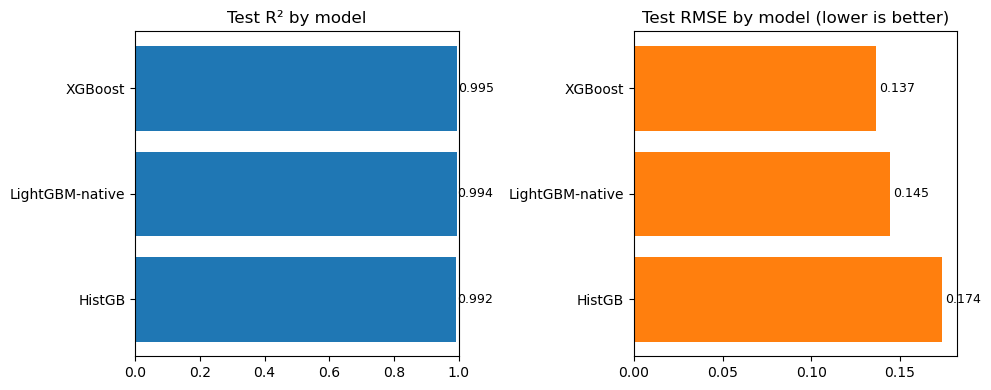

In [26]:
# ---------- Plot: Test metrics by model (R2 and RMSE) ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

if 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError('X_test/y_test not found. Ensure splits and training cells have run.')

rows = []
# XGBoost
if 'xgb' in globals():
    y_pred = xgb.predict(X_test)
    rows.append({'model': 'XGBoost',
                 'R2': r2_score(y_test, y_pred),
                 'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred))),
                 'MAE': float(mean_absolute_error(y_test, y_pred))})
# HistGB
if 'hgb' in globals():
    y_pred = hgb.predict(X_test)
    rows.append({'model': 'HistGB',
                 'R2': r2_score(y_test, y_pred),
                 'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred))),
                 'MAE': float(mean_absolute_error(y_test, y_pred))})
# LightGBM-native
if 'booster' in globals():
    y_pred = booster.predict(X_test, num_iteration=getattr(booster, 'best_iteration', None))
    rows.append({'model': 'LightGBM-native',
                 'R2': r2_score(y_test, y_pred),
                 'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred))),
                 'MAE': float(mean_absolute_error(y_test, y_pred))})
# Ridge (optional, if present)
if 'ridge' in globals():
    try:
        y_pred = ridge.predict(X_test)
        rows.append({'model': 'Ridge',
                     'R2': r2_score(y_test, y_pred),
                     'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred))),
                     'MAE': float(mean_absolute_error(y_test, y_pred))})
    except Exception:
        pass

metrics_df = pd.DataFrame(rows)
if metrics_df.empty:
    print('No trained models detected to plot. Run the model training cells first.')
else:
    metrics_df = metrics_df.sort_values('R2', ascending=True)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # R2 plot
    axes[0].barh(metrics_df['model'], metrics_df['R2'], color='#1f77b4')
    for i, v in enumerate(metrics_df['R2']):
        axes[0].text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)
    axes[0].set_title('Test R² by model')
    axes[0].set_xlim(0.0, 1.0)

    # RMSE plot (lower is better)
    axes[1].barh(metrics_df['model'], metrics_df['RMSE'], color='#ff7f0e')
    for i, v in enumerate(metrics_df['RMSE']):
        axes[1].text(v * 1.01, i, f"{v:.3f}", va='center', fontsize=9)
    axes[1].set_title('Test RMSE by model (lower is better)')

    plt.tight_layout()
    plt.show()


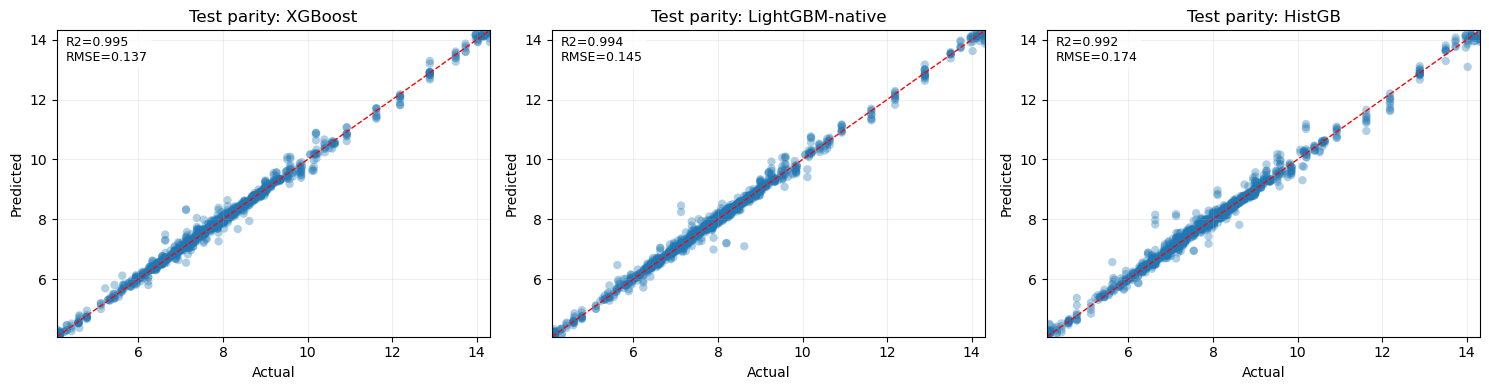

In [27]:
# ---------- Plot: Test parity (Actual vs Predicted) for available models ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

if 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError('X_test/y_test not found. Ensure splits and training cells have run.')

preds = {}
# XGBoost
if 'xgb' in globals():
    try:
        preds['XGBoost'] = xgb.predict(X_test)
    except Exception:
        pass
# LightGBM-native (booster)
if 'booster' in globals():
    try:
        preds['LightGBM-native'] = booster.predict(X_test, num_iteration=getattr(booster, 'best_iteration', None))
    except Exception:
        pass
# HistGB
if 'hgb' in globals():
    try:
        preds['HistGB'] = hgb.predict(X_test)
    except Exception:
        pass
# Ridge (optional)
if 'ridge' in globals():
    try:
        preds['Ridge'] = ridge.predict(X_test)
    except Exception:
        pass
# MLP (sklearn)
if 'mlp_sklearn_predict' in globals() or 'mlp_sklearn' in globals():
    try:
        if 'mlp_sklearn_predict' in globals():
            preds['MLP (sklearn)'] = mlp_sklearn_predict(X_test)
        else:
            preds['MLP (sklearn)'] = mlp_sklearn.predict(X_test)
    except Exception:
        pass
# MLP (Keras)
if 'keras_mlp_predict' in globals() or 'keras_mlp_model' in globals():
    try:
        if 'keras_mlp_predict' in globals():
            preds['MLP (Keras)'] = keras_mlp_predict(X_test)
        else:
            preds['MLP (Keras)'] = keras_mlp_model.predict(X_test, verbose=0).ravel()
    except Exception:
        pass
# MLP (PyTorch)
if 'torch_predict' in globals():
    try:
        preds['MLP (PyTorch)'] = torch_predict(X_test)
    except Exception:
        pass

if len(preds) == 0:
    print('No trained models detected to plot. Run the model training cells first.')
else:
    k = len(preds)
    fig, axes = plt.subplots(1, k, figsize=(5*k, 4), squeeze=False)
    axes = axes[0]

    y_true = y_test
    y_min = float(np.min(y_true))
    y_max = float(np.max(y_true))

    for ax, (name, y_hat) in zip(axes, preds.items()):
        # Parity scatter
        ax.scatter(y_true, y_hat, alpha=0.35, edgecolors='none')
        # Diagonal
        ax.plot([y_min, y_max], [y_min, y_max], 'r--', lw=1)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Test parity: {name}')
        ax.set_xlim(y_min, y_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.2)
        # Metrics annotation
        r2 = r2_score(y_true, y_hat)
        rmse = float(np.sqrt(mean_squared_error(y_true, y_hat)))
        ax.text(0.02, 0.98, f'R2={r2:.3f}\nRMSE={rmse:.3f}', transform=ax.transAxes,
                va='top', ha='left', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, lw=0))

    plt.tight_layout()
    plt.show()


## Discussion of results, hyperparameters, and methods

### Discussion of results
- Generalization is excellent across boosted tree models. Test R² is ≈0.995 (XGBoost), ≈0.994 (LightGBM-native), and ≈0.992 (HistGB), with very low RMSE and tight parity plots along the y=x line.
- The small Train→Validation/Test gap suggests limited overfitting after proper split and scaling (fit scaler on X_train only), and the RFE-selected features are highly predictive.
- Suggested robustness checks: use a time-aware split (if data has temporal order) or GroupKFold by Store; report CV mean±std for R²/RMSE/MAE.

### Hyperparameters used (this run)

| Component | Key hyperparameters |
|---|---|
| Imputation | numeric: SimpleImputer(strategy='mean'); non-numeric: SimpleImputer(strategy='most_frequent') |
| Encoding | LabelEncoder per object column |
| Split | Train/Val/Test = 60/20/20 (random_state=42) |
| Scaling | MinMaxScaler fit on X_train; applied to X_val/X_test |
| Feature selection (RFE) | Estimator: Ridge(alpha=0.01, max_iter=10000); n_features_to_select = 80% of features |
| Ridge (baseline) | alpha=0.01, max_iter=10000 |
| RandomForest | n_estimators=100, random_state=42, n_jobs=-1 |
| XGBoost | n_estimators=2000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=0.0, random_state=42, n_jobs=-1, early_stopping_rounds=50 (with eval_set) |
| LightGBM (native) | objective='regression', metric='rmse', learning_rate=0.05, num_leaves=31, min_child_samples=20, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=0.0, seed=42, verbosity=-1, num_boost_round=2000, early stopping=50 |
| HistGradientBoosting | learning_rate=0.05, max_iter=500, early_stopping=True, validation_fraction=0.2, random_state=42 |
| MLP (sklearn) | hidden_layer_sizes=(64,32), relu, alpha=1e-4, batch_size=64, lr=1e-3, max_iter=1000, early_stopping=True |
| MLP (Keras) | [64,32] with BatchNorm+Dropout(0.10), Adam(lr=1e-3), loss=MSE, EarlyStopping(patience=20, restore_best_weights=True) |
| MLP (PyTorch) | [64,32] with BatchNorm+Dropout(0.10), Adam(lr=1e-3), loss=MSE, EarlyStopping(patience=50) |

### Unique methods used in this notebook
- Data prep: SimpleImputer (mean/most_frequent), LabelEncoder, MinMaxScaler (post-split), duplicate removal
- Split strategy: 60/20/20 Train/Validation/Test with fixed seed
- Feature selection: RFE with Ridge
- Models: Ridge regression, RandomForestRegressor, XGBoost (XGBRegressor), LightGBM (native booster), HistGradientBoostingRegressor, MLP (sklearn), MLP (Keras), MLP (PyTorch)
- Evaluation: R², RMSE, MAE; parity plots; summary tables; optional Bayesian optimization for Ridge (skopt)

### DNNs used (now included)
- MLP (sklearn): Quick baseline multi-layer perceptron with early stopping.
- MLP (Keras): Compact Sequential Dense network with BatchNorm and Dropout, EarlyStopping on val_loss.
- MLP (PyTorch): Compact MLP with BatchNorm/Dropout and a simple early-stopping loop.

All DNNs honor the optional log-transform (USE_LOG) by inverting predictions via inv for fair, original-scale metrics.
